In [1]:
# Importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Leer el archivo CSV desde la URL

In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv"
df = pd.read_csv(url)

 Mostrar primeras filas y tipos de datos

In [3]:
print("Primeras 5 filas:")
print(df.head())
print("\nTipos de datos:")
print(df.dtypes)

Primeras 5 filas:
    mpg  cylinders  displacement  horsepower  weight  acceleration  \
0  18.0          8         307.0       130.0    3504          12.0   
1  15.0          8         350.0       165.0    3693          11.5   
2  18.0          8         318.0       150.0    3436          11.0   
3  16.0          8         304.0       150.0    3433          12.0   
4  17.0          8         302.0       140.0    3449          10.5   

   model_year origin                       name  
0          70    usa  chevrolet chevelle malibu  
1          70    usa          buick skylark 320  
2          70    usa         plymouth satellite  
3          70    usa              amc rebel sst  
4          70    usa                ford torino  

Tipos de datos:
mpg             float64
cylinders         int64
displacement    float64
horsepower      float64
weight            int64
acceleration    float64
model_year        int64
origin           object
name             object
dtype: object


Identificar valores nulos en horsepower

In [4]:
print("\nValores nulos en horsepower:", df['horsepower'].isnull().sum())


Valores nulos en horsepower: 6


Reemplazar valores nulos con la mediana

In [13]:
mediana_hp = np.median(df['horsepower'].dropna())
df.loc[:, 'horsepower'] = df['horsepower'].fillna(mediana_hp)

print("\nValores nulos después de reemplazo:", df['horsepower'].isnull().sum())



Valores nulos después de reemplazo: 0


Crear nueva columna relación peso/potencia

In [6]:
df['relacion_peso_potencia'] = df['weight'] / df['horsepower']
print("\nPrimeras filas con nueva columna:")
print(df[['weight','horsepower','relacion_peso_potencia']].head())



Primeras filas con nueva columna:
   weight  horsepower  relacion_peso_potencia
0    3504       130.0               26.953846
1    3693       165.0               22.381818
2    3436       150.0               22.906667
3    3433       150.0               22.886667
4    3449       140.0               24.635714


Histograma de aceleración

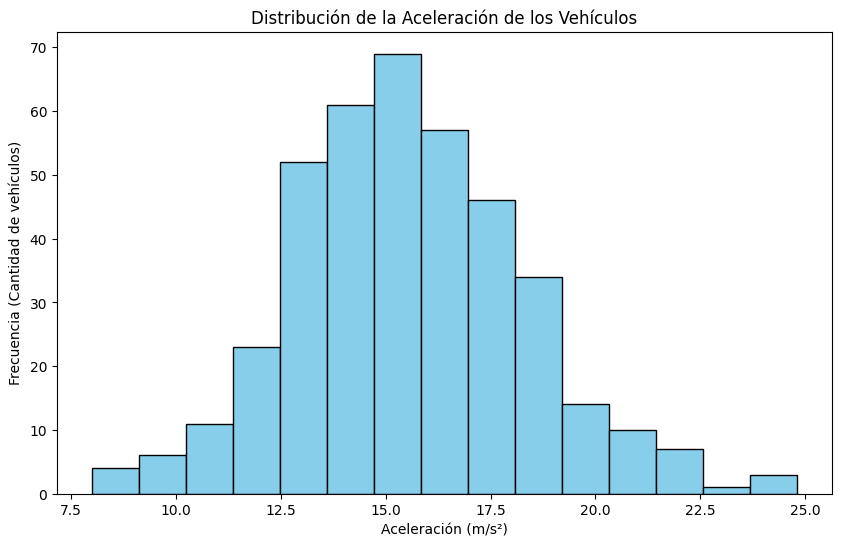

In [12]:
# 1. Histograma: Distribución de la aceleración
plt.figure(figsize=(10, 6))
plt.hist(df['acceleration'], bins=15, color='skyblue', edgecolor='black')
plt.title('Distribución de la Aceleración de los Vehículos')
plt.xlabel('Aceleración (m/s²)')
plt.ylabel('Frecuencia (Cantidad de vehículos)')
plt.show()


 Gráfico de dispersión displacement vs horsepower

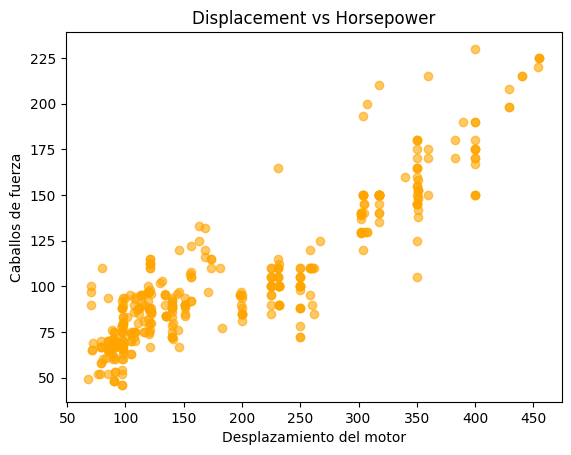

In [8]:
plt.scatter(df['displacement'], df['horsepower'], alpha=0.6, color='orange')
plt.title("Displacement vs Horsepower")
plt.xlabel("Desplazamiento del motor")
plt.ylabel("Caballos de fuerza")
plt.show()

Gráfico de barras: promedio de mpg por país de origen

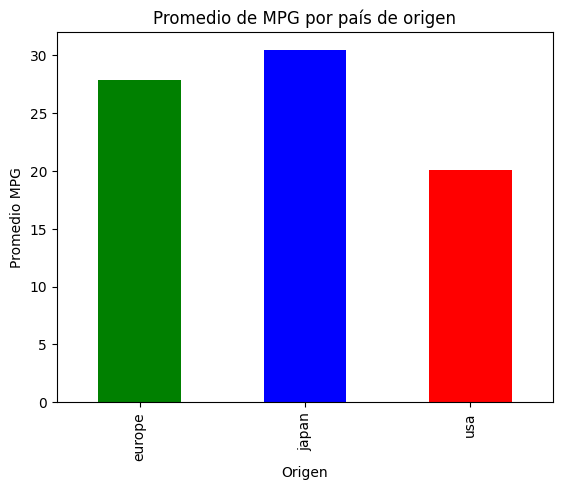

In [9]:
promedio_mpg = df.groupby('origin')['mpg'].mean()
promedio_mpg.plot(kind='bar', color=['green','blue','red'])
plt.title("Promedio de MPG por país de origen")
plt.xlabel("Origen")
plt.ylabel("Promedio MPG")
plt.show()